# Tarea 4 - Punto 4: Problema Inventado (Consumo Energético de Mini-Robot)
En este notebook aplicaremos Programación Genética para realizar **Regresión Simbólica**. El objetivo es encontrar la fórmula matemática que modela el consumo energético de un mini-robot basándonos en su velocidad, peso y la inclinación del terreno.


In [1]:
!pip install deap matplotlib numpy


## 1. Creación del Dataset Simulado
Vamos a generar datos basados en una fórmula real (que el algoritmo no conoce): `Energia = 2 * Velocidad^2 + 0.5 * Peso * Inclinacion + 10`


In [2]:
import random
import math
import operator
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, gp

# Generar datos
random.seed(42)
NUM_SAMPLES = 100

def real_energy(v, p, i):
    return 2 * (v**2) + 0.5 * p * i + 10

dataset = []
for _ in range(NUM_SAMPLES):
    v = random.uniform(0, 5) # Velocidad
    p = random.uniform(1, 10) # Peso
    i = random.uniform(-10, 10) # Inclinación
    e = real_energy(v, p, i) + random.gauss(0, 2) # Añadimos ruido para hacerlo más realista
    dataset.append((v, p, i, e))
    
print("Dataset generado con 100 muestras.")
print("Ejemplo (v, p, i, e):", dataset[0])


Dataset generado con 100 muestras.
Ejemplo (v, p, i, e): (3.1971339922894186, 1.2250967970040025, -4.499413632617615, 28.234420927563725)


## 2. Configuración de Programación Genética
Definimos los conjuntos de funciones (operaciones matemáticas) y terminales (las variables v, p, i y constantes).


In [3]:
def protectedDiv(left, right):
    try: return left / right
    except ZeroDivisionError: return 1.0

pset = gp.PrimitiveSet("MAIN", 3) # 3 variables de entrada: ARG0(v), ARG1(p), ARG2(i)
pset.renameArguments(ARG0="v")
pset.renameArguments(ARG1="p")
pset.renameArguments(ARG2="i")

pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(protectedDiv, 2)
pset.addTerminal(1.0, name="1.0")
pset.addTerminal(2.0, name="2.0")
pset.addTerminal(0.5, name="0.5")
pset.addTerminal(10.0, name="10.0")
# También podemos añadir constantes efímeras
pset.addEphemeralConstant("rand101", lambda: random.uniform(-5, 5))

# Fitness para minimizar el error
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)


c:\Users\kevin\AppData\Local\Programs\Python\Python314\Lib\site-packages\deap\gp.py:257: RuntimeWarning: Ephemeral rand101 function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "


In [4]:
toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)

def evalSymbReg(individual):
    # Compilar el individuo en una función ejecutable
    func = toolbox.compile(expr=individual)
    sqerrors = []
    for v, p, i, real_e in dataset:
        try:
            pred_e = func(v, p, i)
        except:
            pred_e = float('inf')
        sqerrors.append((pred_e - real_e)**2)
    # Retornar el error cuadrático medio
    return math.fsum(sqerrors) / len(dataset),

toolbox.register("evaluate", evalSymbReg)
toolbox.register("select", tools.selTournament, tournsize=5)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)


## 3. Evolución


In [5]:
from deap import algorithms

pop = toolbox.population(n=300)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

print("Iniciando evolución...")
pop, logbook = algorithms.eaSimple(pop, toolbox, 0.7, 0.1, 50, stats=stats, halloffame=hof, verbose=True)
print("¡Evolución terminada!")


Iniciando evolución...
gen	nevals	avg    	std   	min    	max        
0  	300   	13073.3	127297	200.974	2.15286e+06
1  	223   	28028.1	447721	194.593	7.76655e+06
2  	203   	4777.63	47899.4	315.284	783397     
3  	223   	2363.94	11081.3	259.838	169179     
4  	214   	36396.2	525804 	140.223	9.00955e+06
5  	248   	5980.69	72951.6	137.308	1.26439e+06
6  	207   	13888.7	186920 	124.977	3.18084e+06
7  	231   	2232.71	8362.57	124.977	88461.8    
8  	216   	1550.69	5754.6 	124.977	81416.8    
9  	208   	1931.71	8256.68	133.967	97681.5    
10 	219   	91440.5	1.51914e+06	137.308	2.63587e+07
11 	223   	2775.65	16611.5    	137.308	255914     
12 	201   	1954.21	4975.33    	137.308	25360.9    
13 	214   	2142.38	7485.79    	137.308	79583      
14 	214   	9923.52	103858     	137.308	1.29801e+06
15 	208   	33386.5	542676     	137.308	9.41619e+06
16 	236   	5767.79	74297.3    	137.308	1.28852e+06
17 	239   	1897.19	5558.98    	136.061	56295.1    
18 	223   	2107.01	5460.06    	136.061	30881.6    
19 	

## 4. Resultados y Visualización
Mostramos el mejor modelo matemático encontrado y comparamos sus predicciones con los datos reales.


Mejor fórmula encontrada:
 mul(v, add(protectedDiv(i, add(p, add(0.5, add(mul(0.5, -1.2150989700566548), add(protectedDiv(add(v, i), add(protectedDiv(mul(p, 2.0), add(v, 1.0)), p)), sub(sub(1.0, i), sub(1.0, 0.5))))))), add(protectedDiv(add(v, 1.0), add(add(add(i, p), add(i, 10.0)), p)), add(i, 10.0))))


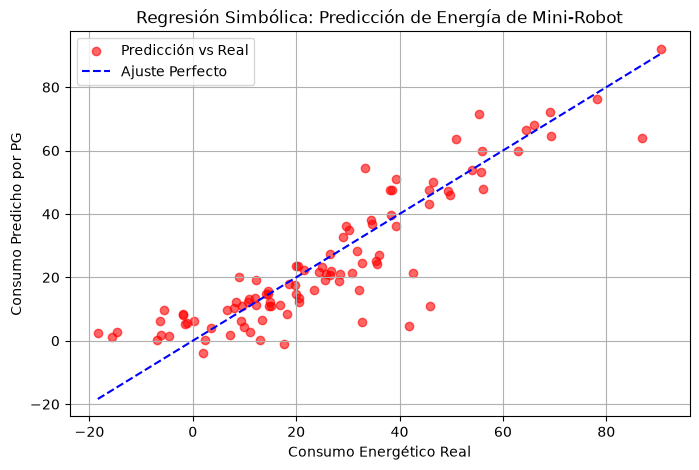

In [6]:
best_model = hof[0]
print("Mejor fórmula encontrada:\n", best_model)

func = toolbox.compile(expr=best_model)
predicciones = [func(v, p, i) for v, p, i, _ in dataset]
reales = [e for _, _, _, e in dataset]

plt.figure(figsize=(8,5))
plt.scatter(reales, predicciones, color='red', alpha=0.6, label='Predicción vs Real')
plt.plot([min(reales), max(reales)], [min(reales), max(reales)], color='blue', linestyle='--', label='Ajuste Perfecto')
plt.xlabel('Consumo Energético Real')
plt.ylabel('Consumo Predicho por PG')
plt.title('Regresión Simbólica: Predicción de Energía de Mini-Robot')
plt.legend()
plt.grid(True)
plt.show()
